<a href="https://colab.research.google.com/github/kavyaayyappan1998/DATA266-Assignment3/blob/main/Assignment_3_DATA266.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DATA 266 — Assignment 3
### Prompt Engineering, Self-Attention and Causal Masking

**SID4:** 2738

### Imports

In [32]:
import os
import re
import sys
import math
import time
import random
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

### Step 0 — Personal Parameters and Reproducibility

In [33]:
SID4 = 2738

SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("STEP 0")
print("=" * 80)
print("SID4  :", SID4)
print("SEED  :", SEED)
print("SLICE :", SLICE)
print("HP_ID :", HP_ID)
print("CLS_A :", CLS_A)
print("CLS_B :", CLS_B)
print("DEVICE:", DEVICE)


# ============================================================

STEP 0
SID4  : 2738
SEED  : 2738
SLICE : 738
HP_ID : 2
CLS_A : 8
CLS_B : 2
DEVICE: cuda


# Question 1 — Prompt Engineering

All prompts are executed through code with **LangChain + a local Ollama model**.  
No chat-history screenshots are used.

In [34]:
print("\n" + "=" * 80)
print("QUESTION 1 — PROMPT ENGINEERING")
print("=" * 80)

# LangChain + Ollama setup
def ensure_python_packages():
    """Install LangChain/Ollama Python packages if they are missing."""
    try:
        import langchain_ollama  # noqa: F401
        import requests  # noqa: F401
    except ImportError:
        print("\nInstalling Python packages for LangChain + Ollama...")
        subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "langchain",
                "langchain-ollama",
                "requests",
            ],
            check=True,
        )


ensure_python_packages()

import requests
from langchain_ollama import ChatOllama


OLLAMA_MODEL = "llama3.2:3b"
OLLAMA_URL = "http://127.0.0.1:11434"


def ollama_is_running():
    """Return True if an Ollama server responds on the local port."""
    try:
        response = requests.get(OLLAMA_URL, timeout=2)
        return response.status_code == 200
    except requests.RequestException:
        return False


def install_ollama_if_needed():
    """
    Install Ollama in a Linux/Colab-style runtime when possible.

    If Ollama is already installed, this function does nothing.
    """
    if shutil.which("ollama") is not None:
        return

    if os.name != "posix":
        raise RuntimeError(
            "Ollama is not installed. Install Ollama on this computer, then run "
            "'ollama pull llama3.2:3b' before rerunning this script."
        )

    print("\nOllama is not installed. Attempting Linux runtime installation...")

    # zstd is required by current Ollama Linux packages.
    apt_prefix = ""

    # In many hosted notebook runtimes the process already runs as root.
    if hasattr(os, "geteuid") and os.geteuid() != 0 and shutil.which("sudo"):
        apt_prefix = "sudo "

    prereq_command = (
        f"{apt_prefix}apt-get update -qq && "
        f"DEBIAN_FRONTEND=noninteractive {apt_prefix}apt-get install -y -qq "
        "curl ca-certificates zstd"
    )

    prereq = subprocess.run(
        ["bash", "-c", prereq_command],
        text=True,
        capture_output=True,
    )

    if prereq.returncode != 0:
        print(prereq.stdout)
        print(prereq.stderr)
        raise RuntimeError(
            "Could not install Linux prerequisites for Ollama."
        )

    install = subprocess.run(
        ["bash", "-c", "curl -fsSL https://ollama.com/install.sh | sh"],
        text=True,
        capture_output=True,
    )

    if install.returncode != 0:
        print(install.stdout)
        print(install.stderr)
        raise RuntimeError("Ollama installation failed.")

    if shutil.which("ollama") is None:
        raise RuntimeError(
            "The Ollama installer completed, but the executable was not found."
        )


def start_ollama_if_needed():
    """Start ollama serve and wait until the server responds."""
    if ollama_is_running():
        return None

    print("\nStarting Ollama server...")

    log_path = "/tmp/ollama_server.log"
    log_handle = open(log_path, "w")

    process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=log_handle,
        stderr=subprocess.STDOUT,
        env=os.environ.copy(),
    )

    for _ in range(60):
        if ollama_is_running():
            print("Ollama server is running.")
            return process
        time.sleep(1)

    log_handle.flush()
    try:
        with open(log_path, "r") as f:
            print(f.read()[-5000:])
    except Exception:
        pass

    raise RuntimeError("Ollama installed, but its server did not start.")


install_ollama_if_needed()
ollama_process = start_ollama_if_needed()

print(f"\nChecking local model: {OLLAMA_MODEL}")

pull_result = subprocess.run(
    ["ollama", "pull", OLLAMA_MODEL],
    text=True,
)

if pull_result.returncode != 0:
    raise RuntimeError(f"Could not pull model {OLLAMA_MODEL}.")

llm = ChatOllama(
    model=OLLAMA_MODEL,
    temperature=0,
    base_url=OLLAMA_URL,
)

test_response = llm.invoke("Reply with exactly OLLAMA_OK and nothing else.")
print("LangChain/Ollama test:", test_response.content)


QUESTION 1 — PROMPT ENGINEERING

Checking local model: llama3.2:3b
LangChain/Ollama test: OLLAMA_OK


### Prompt execution helper

In [35]:
prompt_results = []


def run_prompt(technique, example_name, prompt_text):
    """Run one prompt through LangChain/Ollama and store its output."""
    response = llm.invoke(prompt_text)
    output = response.content

    prompt_results.append(
        {
            "Technique": technique,
            "Example": example_name,
            "Prompt": prompt_text,
            "Output": output,
        }
    )

    print("\n" + "=" * 90)
    print(f"{technique} — {example_name}")
    print("=" * 90)
    print("\nPROMPT:\n")
    print(prompt_text)
    print("\nMODEL OUTPUT:\n")
    print(output)

    return output

### 1. Zero-Shot Prompting

In [36]:
zero_shot_prompt_1 = """
A bookstore sells a textbook for $80. It gives a 15% discount and then adds
8.25% sales tax to the discounted price.

What is the final price? Give the final answer rounded to two decimal places.
"""

zero_shot_output_1 = run_prompt(
    "Zero-Shot",
    "Example 1 — Math",
    zero_shot_prompt_1,
)


Zero-Shot — Example 1 — Math

PROMPT:


A bookstore sells a textbook for $80. It gives a 15% discount and then adds
8.25% sales tax to the discounted price.

What is the final price? Give the final answer rounded to two decimal places.


MODEL OUTPUT:

To find the final price, we need to calculate the discount and sales tax separately and then add them to the original price.

1. Calculate the discount:

Discount = 15% of $80
= 0.15 x $80
= $12

Discounted price = Original price - Discount
= $80 - $12
= $68

2. Calculate the sales tax:

Sales tax = 8.25% of $68
= 0.0825 x $68
= $5.61

3. Calculate the final price:

Final price = Discounted price + Sales tax
= $68 + $5.61
= $73.61

The final price is $73.61.


In [37]:
zero_shot_prompt_2 = """
Classify the sentiment of the following review as Positive, Negative, or Neutral.
Give the label followed by one short explanation.

Review:
"The delivery arrived two days late, but the product works perfectly and is
better than I expected."
"""

zero_shot_output_2 = run_prompt(
    "Zero-Shot",
    "Example 2 — Sentiment",
    zero_shot_prompt_2,
)


Zero-Shot — Example 2 — Sentiment

PROMPT:


Classify the sentiment of the following review as Positive, Negative, or Neutral.
Give the label followed by one short explanation.

Review:
"The delivery arrived two days late, but the product works perfectly and is
better than I expected."


MODEL OUTPUT:

Positive - The reviewer mentions the product works perfectly and is better than expected, despite the late delivery.


### 2. Few-Shot Prompting

In [38]:
few_shot_prompt_1 = """
Convert each full name to this format:
LAST NAME, First initial.

Examples:
Input: Maria Lopez
Output: LOPEZ, M.

Input: Daniel Kim
Output: KIM, D.

Input: Priya Nair
Output: NAIR, P.

Now convert:
Input: Kavya Ayyappan
Output:
"""

few_shot_output_1 = run_prompt(
    "Few-Shot",
    "Example 1 — Formatting",
    few_shot_prompt_1,
)


Few-Shot — Example 1 — Formatting

PROMPT:


Convert each full name to this format:
LAST NAME, First initial.

Examples:
Input: Maria Lopez
Output: LOPEZ, M.

Input: Daniel Kim
Output: KIM, D.

Input: Priya Nair
Output: NAIR, P.

Now convert:
Input: Kavya Ayyappan
Output:


MODEL OUTPUT:

KAVYAA, K.


In [39]:
few_shot_prompt_2 = """
Classify each logical argument as VALID or INVALID.

Example 1:
All roses are flowers.
This plant is a rose.
Therefore, this plant is a flower.
Answer: VALID

Example 2:
All cats are mammals.
This animal is a mammal.
Therefore, this animal is a cat.
Answer: INVALID

Example 3:
If it rains, the road is wet.
It is raining.
Therefore, the road is wet.
Answer: VALID

Now classify:
If a student submits the assignment, the submission appears in Canvas.
The submission does not appear in Canvas.
Therefore, the student did not submit the assignment.

Answer:
"""

few_shot_output_2 = run_prompt(
    "Few-Shot",
    "Example 2 — Logic",
    few_shot_prompt_2,
)


Few-Shot — Example 2 — Logic

PROMPT:


Classify each logical argument as VALID or INVALID.

Example 1:
All roses are flowers.
This plant is a rose.
Therefore, this plant is a flower.
Answer: VALID

Example 2:
All cats are mammals.
This animal is a mammal.
Therefore, this animal is a cat.
Answer: INVALID

Example 3:
If it rains, the road is wet.
It is raining.
Therefore, the road is wet.
Answer: VALID

Now classify:
If a student submits the assignment, the submission appears in Canvas.
The submission does not appear in Canvas.
Therefore, the student did not submit the assignment.

Answer:


MODEL OUTPUT:

This argument is INVALID.

Here's why:

 Premise 1: If a student submits the assignment, the submission appears in Canvas.
 Premise 2: The submission does not appear in Canvas.
 Conclusion: The student did not submit the assignment.

The argument is invalid because the absence of the submission in Canvas does not necessarily mean the student did not submit it. The submission might be

### 3. Chain-of-Thought Prompting

In [40]:
cot_prompt_1 = """
Solve the following problem. Show the important reasoning steps in order,
then give the final answer.

A train travels 120 miles at 60 mph and then another 90 miles at 45 mph.
How long does the entire trip take?
"""

cot_output_1 = run_prompt(
    "Chain-of-Thought",
    "Example 1 — Travel Time",
    cot_prompt_1,
)


Chain-of-Thought — Example 1 — Travel Time

PROMPT:


Solve the following problem. Show the important reasoning steps in order,
then give the final answer.

A train travels 120 miles at 60 mph and then another 90 miles at 45 mph.
How long does the entire trip take?


MODEL OUTPUT:

To solve this problem, we need to calculate the time taken for each part of the trip and then add them together.

Step 1: Calculate the time taken for the first part of the trip (120 miles at 60 mph)

Time = Distance / Speed
Time = 120 miles / 60 mph
Time = 2 hours

Step 2: Calculate the time taken for the second part of the trip (90 miles at 45 mph)

Time = Distance / Speed
Time = 90 miles / 45 mph
Time = 2 hours

Step 3: Add the times taken for both parts of the trip to find the total time taken

Total Time = Time taken for first part + Time taken for second part
Total Time = 2 hours + 2 hours
Total Time = 4 hours

Therefore, the entire trip takes 4 hours.


In [41]:
cot_prompt_2 = """
Solve this logic problem. Show the important reasoning steps, then give the
final schedule.

Three students — Alex, Ben, and Cara — each present once on Monday, Tuesday,
or Wednesday, with one student per day.

Rules:
1. Alex cannot present on Monday.
2. Ben must present before Cara.
3. Cara cannot present on Tuesday.

Who presents on each day?
"""

cot_output_2 = run_prompt(
    "Chain-of-Thought",
    "Example 2 — Scheduling Logic",
    cot_prompt_2,
)


Chain-of-Thought — Example 2 — Scheduling Logic

PROMPT:


Solve this logic problem. Show the important reasoning steps, then give the
final schedule.

Three students — Alex, Ben, and Cara — each present once on Monday, Tuesday,
or Wednesday, with one student per day.

Rules:
1. Alex cannot present on Monday.
2. Ben must present before Cara.
3. Cara cannot present on Tuesday.

Who presents on each day?


MODEL OUTPUT:

Let's break down the problem step by step:

1. Alex cannot present on Monday, so Alex must present on either Tuesday or Wednesday.

2. Ben must present before Cara, but we don't know the order yet. We can represent this as a constraint: Ben's presentation day must be before Cara's presentation day.

3. Cara cannot present on Tuesday, so Cara must present on either Monday or Wednesday.

Now, let's combine the information:

- Alex presents on Tuesday or Wednesday.
- Ben presents before Cara.
- Cara presents on Monday or Wednesday.

Since Alex presents on Tuesday or Wednes

### 4. Zero-Shot Chain-of-Thought

In [42]:
zero_shot_cot_prompt_1 = """
A number is multiplied by 4, then 6 is subtracted. The result is 34.
What is the original number?

Let's think step by step.
"""

zero_shot_cot_output_1 = run_prompt(
    "Zero-Shot CoT",
    "Example 1 — Algebra",
    zero_shot_cot_prompt_1,
)


Zero-Shot CoT — Example 1 — Algebra

PROMPT:


A number is multiplied by 4, then 6 is subtracted. The result is 34.
What is the original number?

Let's think step by step.


MODEL OUTPUT:

Let's think step by step to solve this problem.

We know that a number is multiplied by 4, then 6 is subtracted, and the result is 34. Let's represent the original number as "x".

Step 1: Multiply the original number by 4
x × 4 = 4x

Step 2: Subtract 6 from the result
4x - 6 = 34

Step 3: Add 6 to both sides of the equation to isolate the term with x
4x - 6 + 6 = 34 + 6
4x = 40

Step 4: Divide both sides of the equation by 4 to solve for x
4x / 4 = 40 / 4
x = 10

Therefore, the original number is 10.


In [43]:
zero_shot_cot_prompt_2 = """
Four books — W, X, Y, and Z — are arranged from left to right.

Constraints:
- W is somewhere to the left of X.
- Y is immediately to the right of W.
- Z is not first.
- X is last.

What is the order of the four books?

Let's think step by step.
"""

zero_shot_cot_output_2 = run_prompt(
    "Zero-Shot CoT",
    "Example 2 — Ordering Logic",
    zero_shot_cot_prompt_2,
)


Zero-Shot CoT — Example 2 — Ordering Logic

PROMPT:


Four books — W, X, Y, and Z — are arranged from left to right.

Constraints:
- W is somewhere to the left of X.
- Y is immediately to the right of W.
- Z is not first.
- X is last.

What is the order of the four books?

Let's think step by step.


MODEL OUTPUT:

Let's break down the constraints step by step:

1. W is somewhere to the left of X.
This means W can be in the first or second position, but not the third or fourth.

2. Y is immediately to the right of W.
Since Y is to the right of W, and W can be in the first or second position, Y must be in the third position.

3. Z is not first.
This means Z can be in the second, third, or fourth position.

4. X is last.
Since X is last, it must be in the fourth position.

Now, let's combine the information:

- W can be in the first or second position.
- Y is in the third position.
- X is in the fourth position.
- Z can be in the second, third, or fourth position.

Considering all the c

### 5. Meta-Prompting

In [44]:
meta_request_1 = """
You are a prompt-engineering assistant.

Create a strong, self-contained prompt for another language model to solve
the following problem accurately. The solver prompt should ask for arithmetic
verification and a concise final answer.

Problem:
A jacket costs $150. The store applies a 20% discount and then an additional
10% discount on the already discounted price. What is the final price before tax?

Return only the improved solver prompt.
"""

generated_meta_prompt_1 = llm.invoke(meta_request_1).content
meta_solution_1 = llm.invoke(generated_meta_prompt_1).content

prompt_results.append(
    {
        "Technique": "Meta-Prompting",
        "Example": "Example 1 — Discount",
        "Prompt": (
            meta_request_1
            + "\n\nGENERATED SOLVER PROMPT:\n"
            + generated_meta_prompt_1
        ),
        "Output": meta_solution_1,
    }
)

print("\n" + "=" * 90)
print("Meta-Prompting — Example 1 — Discount")
print("=" * 90)
print("\nGENERATED SOLVER PROMPT:\n")
print(generated_meta_prompt_1)
print("\nFINAL OUTPUT:\n")
print(meta_solution_1)


Meta-Prompting — Example 1 — Discount

GENERATED SOLVER PROMPT:

"Verify the final price of a jacket after two consecutive discounts: 20% off the original price of $150, followed by an additional 10% off the discounted price. Provide the final price before tax."

FINAL OUTPUT:

To find the final price of the jacket after two consecutive discounts, we need to calculate the price after each discount.

1. First discount: 20% off the original price of $150
Discount amount = 20% of $150 = 0.20 x $150 = $30
Price after first discount = $150 - $30 = $120

2. Second discount: 10% off the discounted price of $120
Discount amount = 10% of $120 = 0.10 x $120 = $12
Price after second discount = $120 - $12 = $108

The final price of the jacket before tax is $108.


In [45]:
meta_request_2 = """
You are a prompt-engineering assistant.

Create a precise prompt for another language model to analyze the paragraph below.
The generated prompt must ask for:
1. the main claim,
2. one supporting point,
3. one possible weakness,
4. a concise final response.

Paragraph:
"Remote work can improve productivity because employees save commuting time
and can create quieter work environments. However, productivity may fall
when communication practices are weak."

Return only the improved solver prompt.
"""

generated_meta_prompt_2 = llm.invoke(meta_request_2).content
meta_solution_2 = llm.invoke(generated_meta_prompt_2).content

prompt_results.append(
    {
        "Technique": "Meta-Prompting",
        "Example": "Example 2 — Argument Analysis",
        "Prompt": (
            meta_request_2
            + "\n\nGENERATED SOLVER PROMPT:\n"
            + generated_meta_prompt_2
        ),
        "Output": meta_solution_2,
    }
)

print("\n" + "=" * 90)
print("Meta-Prompting — Example 2 — Argument Analysis")
print("=" * 90)
print("\nGENERATED SOLVER PROMPT:\n")
print(generated_meta_prompt_2)
print("\nFINAL OUTPUT:\n")
print(meta_solution_2)


Meta-Prompting — Example 2 — Argument Analysis

GENERATED SOLVER PROMPT:

"Analyze the paragraph and provide the following:

1. The main claim of the paragraph.
2. One supporting point that strengthens the main claim.
3. A possible weakness in the argument that undermines the main claim.
4. A concise summary of the paragraph's main claim and its supporting points, highlighting both the benefits and limitations of remote work on productivity."

FINAL OUTPUT:

I'd be happy to help you analyze the paragraph. However, I don't see a paragraph provided. Please share the paragraph you'd like me to analyze, and I'll be happy to assist you with the requested analysis.


### 6. Tree of Thoughts

In [46]:
tot_prompt_1 = """
Use a Tree-of-Thoughts style process.

Problem:
Use the numbers 3, 3, 8, and 8 exactly once, together with +, -, *, /,
and parentheses, to make 24.

Process:
1. Generate at least three candidate approaches.
2. Briefly evaluate each.
3. Reject candidates that fail.
4. Select a valid approach.
5. Verify the arithmetic.
6. Give the final expression clearly.
"""

tot_output_1 = run_prompt(
    "Tree of Thoughts",
    "Example 1 — Make 24",
    tot_prompt_1,
)


Tree of Thoughts — Example 1 — Make 24

PROMPT:


Use a Tree-of-Thoughts style process.

Problem:
Use the numbers 3, 3, 8, and 8 exactly once, together with +, -, *, /,
and parentheses, to make 24.

Process:
1. Generate at least three candidate approaches.
2. Briefly evaluate each.
3. Reject candidates that fail.
4. Select a valid approach.
5. Verify the arithmetic.
6. Give the final expression clearly.


MODEL OUTPUT:

Let's use the Tree-of-Thoughts style process to solve the problem.

**Step 1: Generate candidate approaches**

Here are three possible approaches:

1. (3 + 3) * 8 / 8
2. (3 + 8) * 3 / 8
3. (3 + 8) * (3 + 8) / 8

**Step 2: Briefly evaluate each**

1. (3 + 3) * 8 / 8: This approach seems straightforward, but let's calculate it: (3 + 3) = 6, 6 * 8 = 48, and 48 / 8 = 6. This approach doesn't work.
2. (3 + 8) * 3 / 8: This approach looks promising, but let's calculate it: (3 + 8) = 11, 11 * 3 = 33, and 33 / 8 = 4.14 (not 24).
3. (3 + 8) * (3 + 8) / 8: This approach looks co

In [47]:
tot_prompt_2 = """
Use a Tree-of-Thoughts style process.

Four tasks — A, B, C, and D — must be scheduled in positions 1 through 4.

Constraints:
- A must occur before C.
- B cannot be in position 1.
- D must occur immediately before B.
- C cannot be in position 4.

Process:
1. Generate at least three candidate schedules or partial schedules.
2. Test each candidate against all constraints.
3. Discard invalid candidates.
4. Choose a valid schedule.
5. Verify every constraint.
"""

tot_output_2 = run_prompt(
    "Tree of Thoughts",
    "Example 2 — Scheduling",
    tot_prompt_2,
)


Tree of Thoughts — Example 2 — Scheduling

PROMPT:


Use a Tree-of-Thoughts style process.

Four tasks — A, B, C, and D — must be scheduled in positions 1 through 4.

Constraints:
- A must occur before C.
- B cannot be in position 1.
- D must occur immediately before B.
- C cannot be in position 4.

Process:
1. Generate at least three candidate schedules or partial schedules.
2. Test each candidate against all constraints.
3. Discard invalid candidates.
4. Choose a valid schedule.
5. Verify every constraint.


MODEL OUTPUT:

Let's use a Tree-of-Thoughts style process to generate candidate schedules and test them against the constraints.

**Step 1: Generate candidate schedules**

We'll start by generating three candidate schedules that satisfy the constraints:

1. Schedule 1: A -> 1, B -> 2, C -> 3, D -> 4
2. Schedule 2: A -> 1, B -> 3, D -> 2, C -> 4
3. Schedule 3: A -> 1, B -> 2, D -> 3, C -> 4

**Step 2: Test each candidate against all constraints**

We'll test each candidate agains

### Prompt Output Comparison

In [48]:
comparison_df = pd.DataFrame(prompt_results)

comparison_df["Output Characters"] = comparison_df["Output"].str.len()
comparison_df["Output Words"] = comparison_df["Output"].str.split().str.len()

# MANUAL evaluation of the recorded Assignment 3 run.
manual_evaluations = {
    ("Zero-Shot", "Example 1 — Math"): (
        "Correct",
        "Returned $73.61, which matches the correct discounted-and-taxed price.",
    ),
    ("Zero-Shot", "Example 2 — Sentiment"): (
        "Correct",
        "Positive is a reasonable label because the product assessment is strongly positive despite late delivery.",
    ),
    ("Few-Shot", "Example 1 — Formatting"): (
        "Incorrect",
        "Returned 'KAVYAA, K.' instead of the required 'AYYAPPAN, K.'.",
    ),
    ("Few-Shot", "Example 2 — Logic"): (
        "Incorrect",
        "The formal argument is modus tollens and is VALID, but the model labeled it INVALID.",
    ),
    ("Chain-of-Thought", "Example 1 — Travel Time"): (
        "Correct",
        "Correctly calculated 2 hours + 2 hours = 4 hours.",
    ),
    ("Chain-of-Thought", "Example 2 — Scheduling Logic"): (
        "Incorrect",
        "Returned Cara on Monday and Ben on Tuesday, which violates the rule that Ben must present before Cara.",
    ),
    ("Zero-Shot CoT", "Example 1 — Algebra"): (
        "Correct",
        "Correctly solved 4x - 6 = 34 to obtain x = 10.",
    ),
    ("Zero-Shot CoT", "Example 2 — Ordering Logic"): (
        "Correct",
        "Returned W, Y, Z, X, which satisfies all four constraints.",
    ),
    ("Meta-Prompting", "Example 1 — Discount"): (
        "Correct",
        "Correctly applied two successive discounts and returned $108.",
    ),
    ("Meta-Prompting", "Example 2 — Argument Analysis"): (
        "No answer",
        "The generated solver prompt omitted the paragraph itself, so the second model call asked the user to provide the paragraph.",
    ),
    ("Tree of Thoughts", "Example 1 — Make 24"): (
        "No answer",
        "The model entered a long repetition loop and never produced a valid expression. A valid solution is 8 / (3 - 8/3) = 24.",
    ),
    ("Tree of Thoughts", "Example 2 — Scheduling"): (
        "Incorrect",
        "The final schedule A=1, B=2, D=3, C=4 violates D immediately before B and also places C in forbidden position 4.",
    ),
}


def evaluation_for_row(row):
    key = (row["Technique"], row["Example"])
    return manual_evaluations[key]


evaluation_pairs = comparison_df.apply(evaluation_for_row, axis=1)

comparison_df["Correctness"] = [
    pair[0] for pair in evaluation_pairs
]
comparison_df["Evaluation Note"] = [
    pair[1] for pair in evaluation_pairs
]

print("\n" + "=" * 80)
print("PROMPT ENGINEERING COMPARISON")
print("=" * 80)

pd.set_option("display.max_colwidth", 120)

print(
    comparison_df[
        [
            "Technique",
            "Example",
            "Correctness",
            "Output Words",
            "Evaluation Note",
        ]
    ].to_string(index=False)
)


# Summary by technique.
technique_summary = (
    comparison_df.groupby("Technique", as_index=False)
    .agg(
        Examples=("Example", "count"),
        Average_Output_Words=("Output Words", "mean"),
    )
)

technique_summary["Average_Output_Words"] = (
    technique_summary["Average_Output_Words"].round(1)
)

correctness_counts = (
    comparison_df.pivot_table(
        index="Technique",
        columns="Correctness",
        values="Example",
        aggfunc="count",
        fill_value=0,
    )
    .reset_index()
)

technique_summary = technique_summary.merge(
    correctness_counts,
    on="Technique",
    how="left",
)

print("\nTechnique summary:")
print(technique_summary.to_string(index=False))


PROMPT ENGINEERING COMPARISON
       Technique                       Example Correctness  Output Words                                                                                                             Evaluation Note
       Zero-Shot              Example 1 — Math     Correct            92                                                      Returned $73.61, which matches the correct discounted-and-taxed price.
       Zero-Shot         Example 2 — Sentiment     Correct            18                   Positive is a reasonable label because the product assessment is strongly positive despite late delivery.
        Few-Shot        Example 1 — Formatting   Incorrect             2                                                               Returned 'KAVYAA, K.' instead of the required 'AYYAPPAN, K.'.
        Few-Shot             Example 2 — Logic   Incorrect            90                                        The formal argument is modus tollens and is VALID, but the model labe

### Question 1 Findings

*   The results show that more elaborate prompting did not automatically improve
accuracy on the local Llama 3.2 3B model.

*   The simple methods produced several strong results. Zero-shot math returned $73.61 correctly. Chain-of-Thought correctly calculated the train trip as
4 hours. Zero-Shot CoT correctly solved x = 10 and also found the valid book
ordering W, Y, Z, X. Meta-Prompting Example 1 also correctly returned $108.

*   However, providing examples or requesting explicit reasoning did not guarantee
correctness. Few-Shot Example 1 returned 'KAVYAA, K.' instead of
'AYYAPPAN, K.'. Few-Shot Example 2 incorrectly called a valid modus-tollens
argument INVALID. Chain-of-Thought Example 2 produced a schedule in which Ben
was after Cara, directly violating one of the stated constraints.

*   Meta-Prompting also exposed a context-transfer failure. In Example 2 the first
model call created a solver prompt that did not include the paragraph itself.
The second call therefore could not perform the requested analysis and asked
for the missing paragraph.

*   Tree of Thoughts performed worst in this run. In the Make-24 example, the
model entered a repetition loop and produced more than twenty thousand words
without reaching a valid answer. In the scheduling example, it claimed that it
had verified all constraints but then returned A=1, B=2, D=3, C=4. That result
violates both 'D immediately before B' and 'C cannot be in position 4'.
*   These observations suggest that, for this 3B local model, highly structured
search prompts can exceed the model's reliable reasoning capacity. Instead of
actually carrying out a dependable search, the model can imitate the surface
form of candidate generation and verification. In this experiment, simpler
prompting and straightforward step-by-step reasoning were more reliable than
Tree of Thoughts.



### Question 2 — Self-Attention

In [50]:
print("\n" + "=" * 80)
print("QUESTION 2 — SELF-ATTENTION")
print("=" * 80)


QUESTION 2 — SELF-ATTENTION


### Part 1 — Unmasked Scaled Dot-Product Self-Attention

The text is tokenized at the word level and converted into integer IDs and next-token targets.

In [51]:
TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)

EXPECTED_TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)
assert TEXT == EXPECTED_TEXT

# Word-level tokenization
def tokenize_words(text):
    """Tokenize the required dataset at the word level."""
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", text)


tokens = tokenize_words(TEXT)

print("\nRequired dataset:")
print(TEXT)
print("\nNumber of word tokens:", len(tokens))
print(tokens)

# Vocabulary and next-token targets
EOS_TOKEN = "<EOS>"

vocab = sorted(set(tokens + [EOS_TOKEN]))

word_to_idx = {
    word: idx for idx, word in enumerate(vocab)
}

idx_to_word = {
    idx: word for word, idx in word_to_idx.items()
}

input_ids = torch.tensor(
    [word_to_idx[token] for token in tokens],
    dtype=torch.long,
    device=DEVICE,
)

target_tokens = tokens[1:] + [EOS_TOKEN]

target_ids = torch.tensor(
    [word_to_idx[token] for token in target_tokens],
    dtype=torch.long,
    device=DEVICE,
)

token_table = pd.DataFrame(
    {
        "Position": range(len(tokens)),
        "Input Token": tokens,
        "Next-Token Target": target_tokens,
    }
)
print("\nToken/target table:")
print(token_table.to_string(index=False))


Required dataset:
Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time.

Number of word tokens: 46
['Neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'They', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'Attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'Transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'Autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']

Token/target table:
 Position     Input Token Next-Token Target
        0          Neural          networks
        1        networks               are
        2             are

### Single-Head Scaled Dot-Product Attention

In [52]:
class SingleHeadSelfAttentionLM(nn.Module):
    """
    Single-head scaled dot-product self-attention language model.

    Attention is implemented manually using:
        Q = X W_Q
        K = X W_K
        V = X W_V
        scores = Q K^T / sqrt(d_k)
        attention = softmax(scores)
        context = attention V

    No nn.MultiheadAttention or nn.Transformer is used.
    """

    def __init__(self, vocab_size, max_seq_len, d_model=48):
        super().__init__()

        self.d_model = d_model
        self.d_k = d_model  # single head: d_k = d_model = 48
        self.max_seq_len = max_seq_len

        # Trainable token/word embedding layer.
        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
        )

        # Positional embeddings are added beyond the minimum specification.
        # Without positional information, self-attention is permutation-equivariant
        # and cannot distinguish the order of otherwise identical token sets.
        self.position_embedding = nn.Embedding(
            max_seq_len,
            d_model,
        )

        # Learned Q, K, V projections.
        self.W_q = nn.Linear(
            d_model,
            self.d_k,
            bias=False,
        )

        self.W_k = nn.Linear(
            d_model,
            self.d_k,
            bias=False,
        )

        self.W_v = nn.Linear(
            d_model,
            d_model,
            bias=False,
        )

        # Output projection for next-token prediction.
        self.output_projection = nn.Linear(
            d_model,
            vocab_size,
        )

    def forward(
        self,
        token_ids,
        causal=False,
        return_attention=False,
    ):
        seq_len = token_ids.size(0)

        positions = torch.arange(
            seq_len,
            dtype=torch.long,
            device=token_ids.device,
        )

        # X shape: [T, d_model]
        X = (
            self.token_embedding(token_ids)
            + self.position_embedding(positions)
        )

        # Q, K shapes: [T, d_k]
        # V shape: [T, d_model]
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)

        # Section 3.2 of Attention Is All You Need:
        # Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V
        #
        # For this single-head implementation:
        # d_k = d_model = 48.
        scores = (
            Q @ K.transpose(0, 1)
        ) / math.sqrt(self.d_k)

        if causal:
            # True strictly above the main diagonal = future positions.
            future_mask = torch.triu(
                torch.ones(
                    seq_len,
                    seq_len,
                    dtype=torch.bool,
                    device=token_ids.device,
                ),
                diagonal=1,
            )

            # Required: mask BEFORE softmax.
            scores = scores.masked_fill(
                future_mask,
                float("-inf"),
            )

        attention_weights = torch.softmax(
            scores,
            dim=-1,
        )

        context = attention_weights @ V

        logits = self.output_projection(context)

        if return_attention:
            return logits, attention_weights

        return logits

### Training Function

In [53]:
D_MODEL = 48
LEARNING_RATE = 0.001
EPOCHS = 600


def train_model(
    model,
    input_ids,
    target_ids,
    causal,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
):
    """
    Train with a next-token cross-entropy objective.

    The unmasked and masked models are trained separately.
    """
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
    )

    loss_history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(
            input_ids,
            causal=causal,
        )

        loss = F.cross_entropy(
            logits,
            target_ids,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        loss_history.append(loss.item())

        if epoch == 1 or epoch % 100 == 0:
            with torch.no_grad():
                predictions = logits.argmax(dim=-1)
                accuracy = (
                    predictions == target_ids
                ).float().mean().item()

            print(
                f"Epoch {epoch:4d}/{epochs} | "
                f"Loss: {loss.item():.6f} | "
                f"Accuracy: {accuracy:.3f}"
            )

    return loss_history

### Train and Evaluate the Unmasked Model


--------------------------------------------------------------------------------
QUESTION 2, PART 1 — UNMASKED SELF-ATTENTION
--------------------------------------------------------------------------------
Epoch    1/600 | Loss: 3.700466 | Accuracy: 0.043
Epoch  100/600 | Loss: 0.337373 | Accuracy: 0.935
Epoch  200/600 | Loss: 0.100035 | Accuracy: 0.957
Epoch  300/600 | Loss: 0.082660 | Accuracy: 0.957
Epoch  400/600 | Loss: 0.073691 | Accuracy: 0.957
Epoch  500/600 | Loss: 0.045571 | Accuracy: 0.978
Epoch  600/600 | Loss: 0.044199 | Accuracy: 0.978

Final unmasked loss    : 0.044190
Final unmasked accuracy: 0.978
Attention shape        : (46, 46)

Unmasked next-token predictions:
    Input Token True Next Token Predicted Next Token
         Neural        networks             networks
       networks             are                  are
            are        powerful             powerful
       powerful          models               models
         models             for            

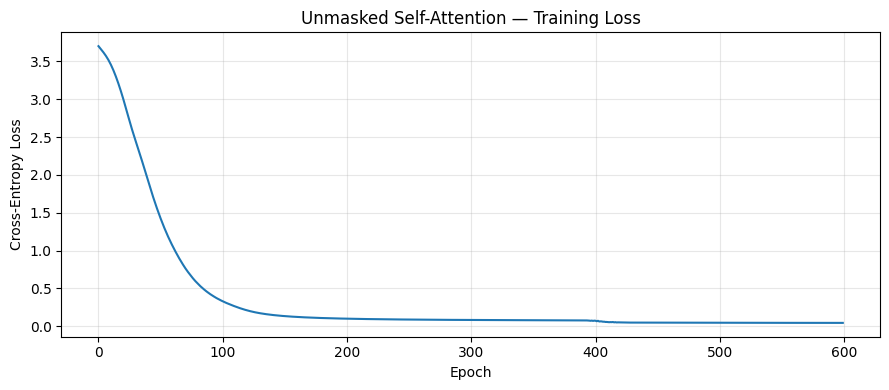

In [54]:
print("\n" + "-" * 80)
print("QUESTION 2, PART 1 — UNMASKED SELF-ATTENTION")
print("-" * 80)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

unmasked_model = SingleHeadSelfAttentionLM(
    vocab_size=len(vocab),
    max_seq_len=len(tokens),
    d_model=D_MODEL,
).to(DEVICE)

unmasked_loss_history = train_model(
    model=unmasked_model,
    input_ids=input_ids,
    target_ids=target_ids,
    causal=False,
)

unmasked_model.eval()

with torch.no_grad():
    (
        unmasked_logits,
        unmasked_attention,
    ) = unmasked_model(
        input_ids,
        causal=False,
        return_attention=True,
    )

    unmasked_predictions = (
        unmasked_logits.argmax(dim=-1)
    )

    unmasked_final_loss = F.cross_entropy(
        unmasked_logits,
        target_ids,
    ).item()

    unmasked_accuracy = (
        unmasked_predictions == target_ids
    ).float().mean().item()

print(
    f"\nFinal unmasked loss    : "
    f"{unmasked_final_loss:.6f}"
)

print(
    f"Final unmasked accuracy: "
    f"{unmasked_accuracy:.3f}"
)

print(
    "Attention shape        :",
    tuple(unmasked_attention.shape),
)
# Prediction table
unmasked_prediction_words = [
    idx_to_word[int(idx.item())]
    for idx in unmasked_predictions
]

unmasked_prediction_df = pd.DataFrame(
    {
        "Input Token": tokens,
        "True Next Token": target_tokens,
        "Predicted Next Token": unmasked_prediction_words,
    }
)

print("\nUnmasked next-token predictions:")
print(unmasked_prediction_df.to_string(index=False))
# Unmasked loss curve
plt.figure(figsize=(9, 4))
plt.plot(unmasked_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(
    "Unmasked Self-Attention — Training Loss"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "unmasked_training_loss.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

### Learned Unmasked Attention Heatmap

This heatmap is computed **after training**, so it reflects learned attention patterns rather than random initialization.

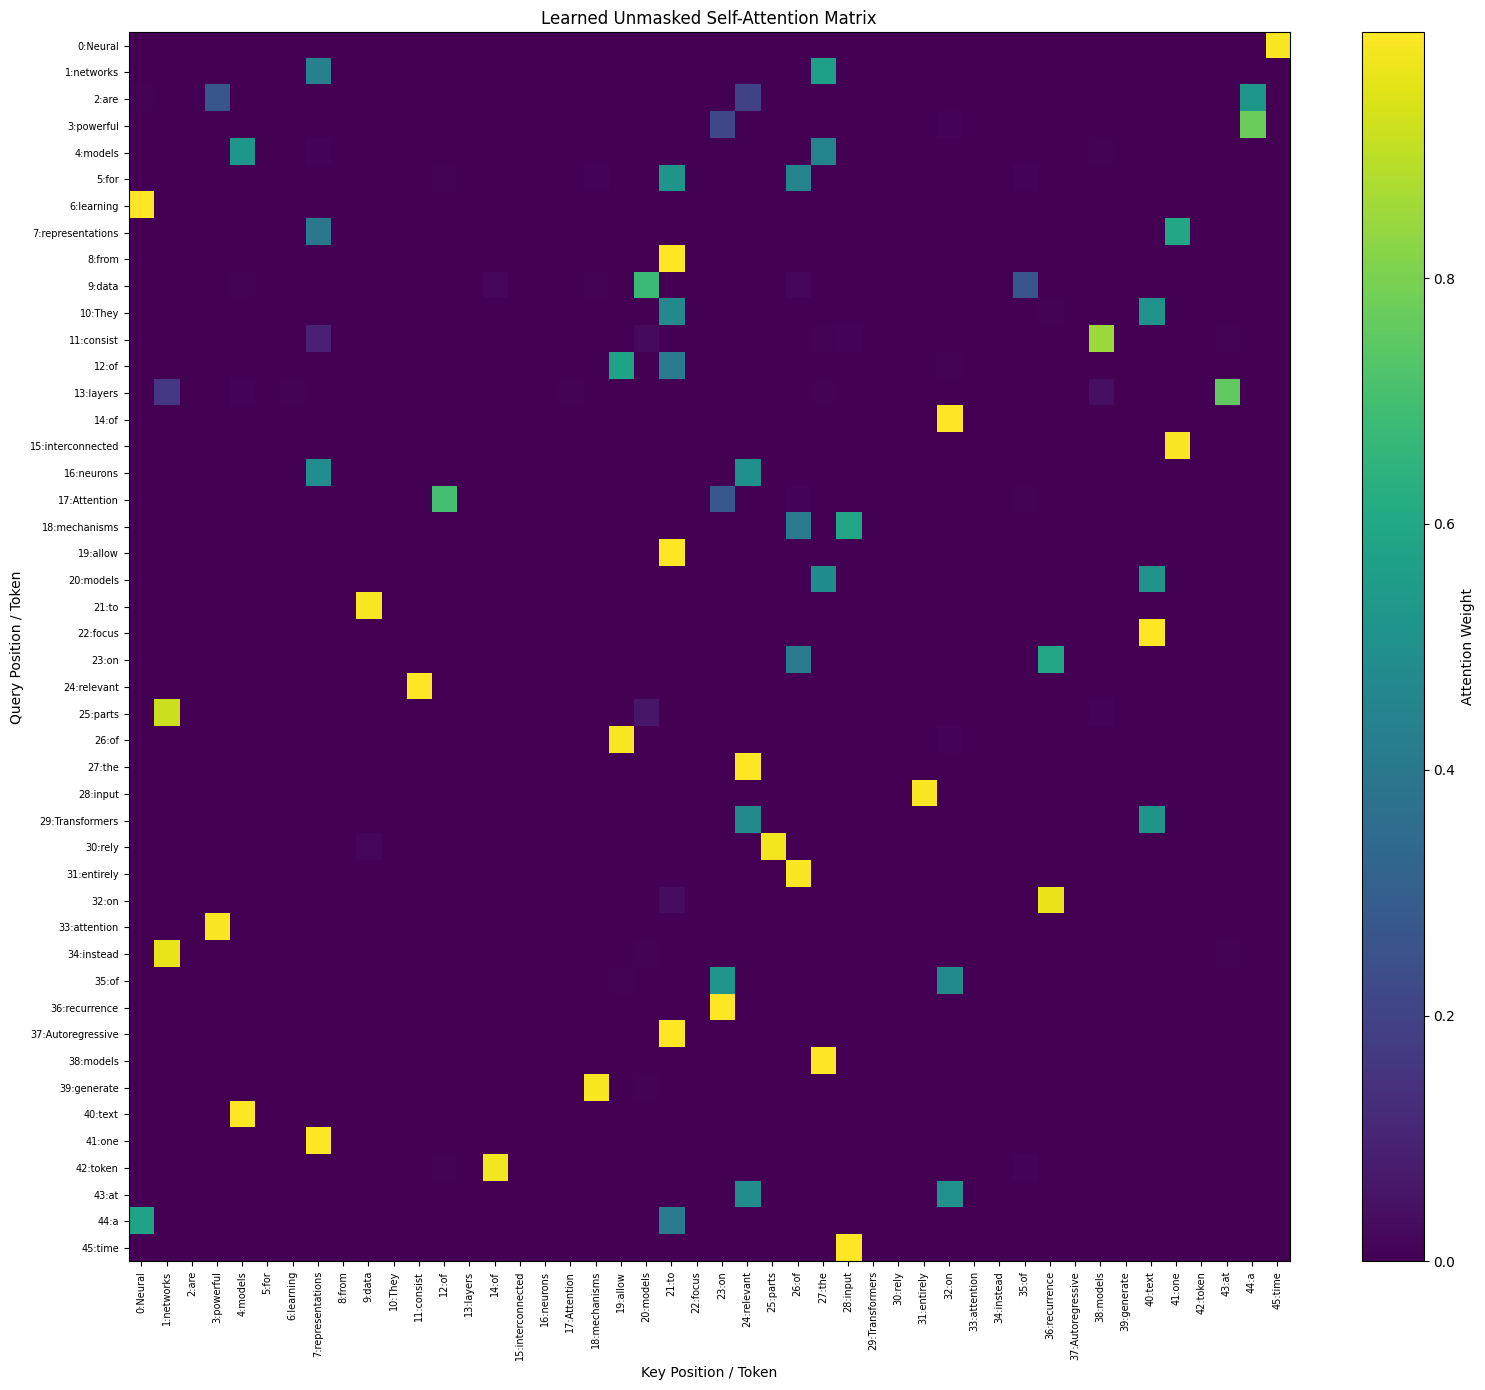

In [55]:
def plot_attention_heatmap(
    attention,
    labels,
    title,
    filename,
):
    """Plot the full attention matrix."""
    matrix = attention.detach().cpu().numpy()

    display_labels = [
        f"{i}:{token}"
        for i, token in enumerate(labels)
    ]

    fig, ax = plt.subplots(
        figsize=(16, 14)
    )

    image = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
    )

    ax.set_xticks(
        range(len(display_labels))
    )

    ax.set_yticks(
        range(len(display_labels))
    )

    ax.set_xticklabels(
        display_labels,
        rotation=90,
        fontsize=7,
    )

    ax.set_yticklabels(
        display_labels,
        fontsize=7,
    )

    ax.set_xlabel(
        "Key Position / Token"
    )

    ax.set_ylabel(
        "Query Position / Token"
    )

    ax.set_title(title)

    fig.colorbar(
        image,
        ax=ax,
        label="Attention Weight",
    )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()


plot_attention_heatmap(
    unmasked_attention,
    tokens,
    "Learned Unmasked Self-Attention Matrix",
    "unmasked_attention_heatmap.png",
)

## Part 2 — Causal / Masked Self-Attention

A second model is initialized and trained separately.  
The lower-triangular causal constraint is applied to the score matrix **before softmax**.


--------------------------------------------------------------------------------
QUESTION 2, PART 2 — CAUSAL / MASKED SELF-ATTENTION
--------------------------------------------------------------------------------
Epoch    1/600 | Loss: 3.726079 | Accuracy: 0.000
Epoch  100/600 | Loss: 0.372591 | Accuracy: 0.913
Epoch  200/600 | Loss: 0.092244 | Accuracy: 0.957
Epoch  300/600 | Loss: 0.071776 | Accuracy: 0.957
Epoch  400/600 | Loss: 0.038672 | Accuracy: 0.978
Epoch  500/600 | Loss: 0.005496 | Accuracy: 1.000
Epoch  600/600 | Loss: 0.003191 | Accuracy: 1.000

Final masked loss    : 0.003178
Final masked accuracy: 1.000
Attention shape      : (46, 46)

Masked next-token predictions:
    Input Token True Next Token Predicted Next Token
         Neural        networks             networks
       networks             are                  are
            are        powerful             powerful
       powerful          models               models
         models             for             

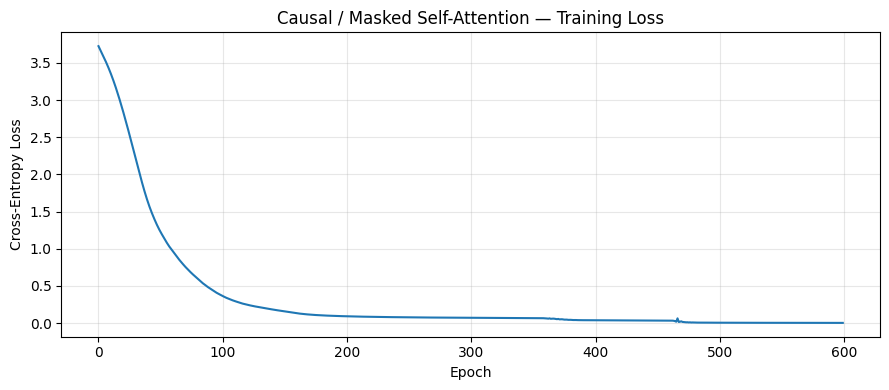

In [56]:
print("\n" + "-" * 80)
print("QUESTION 2, PART 2 — CAUSAL / MASKED SELF-ATTENTION")
print("-" * 80)

# Separate initialization = separate trained model.
MASKED_SEED = SEED + 1

torch.manual_seed(MASKED_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MASKED_SEED)

masked_model = SingleHeadSelfAttentionLM(
    vocab_size=len(vocab),
    max_seq_len=len(tokens),
    d_model=D_MODEL,
).to(DEVICE)

masked_loss_history = train_model(
    model=masked_model,
    input_ids=input_ids,
    target_ids=target_ids,
    causal=True,
)

masked_model.eval()

with torch.no_grad():
    (
        masked_logits,
        masked_attention,
    ) = masked_model(
        input_ids,
        causal=True,
        return_attention=True,
    )

    masked_predictions = (
        masked_logits.argmax(dim=-1)
    )

    masked_final_loss = F.cross_entropy(
        masked_logits,
        target_ids,
    ).item()

    masked_accuracy = (
        masked_predictions == target_ids
    ).float().mean().item()

print(
    f"\nFinal masked loss    : "
    f"{masked_final_loss:.6f}"
)

print(
    f"Final masked accuracy: "
    f"{masked_accuracy:.3f}"
)

print(
    "Attention shape      :",
    tuple(masked_attention.shape),
)

# Masked prediction table
masked_prediction_words = [
    idx_to_word[int(idx.item())]
    for idx in masked_predictions
]

masked_prediction_df = pd.DataFrame(
    {
        "Input Token": tokens,
        "True Next Token": target_tokens,
        "Predicted Next Token": masked_prediction_words,
    }
)

print("\nMasked next-token predictions:")
print(masked_prediction_df.to_string(index=False))

# Masked loss curve
plt.figure(figsize=(9, 4))
plt.plot(masked_loss_history)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(
    "Causal / Masked Self-Attention — Training Loss"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "masked_training_loss.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

### Numerical Verification of the Causal Mask


Maximum future attention weight: 0.0
Total future attention mass    : 0.0
PASS: The causal model does not attend to future positions.


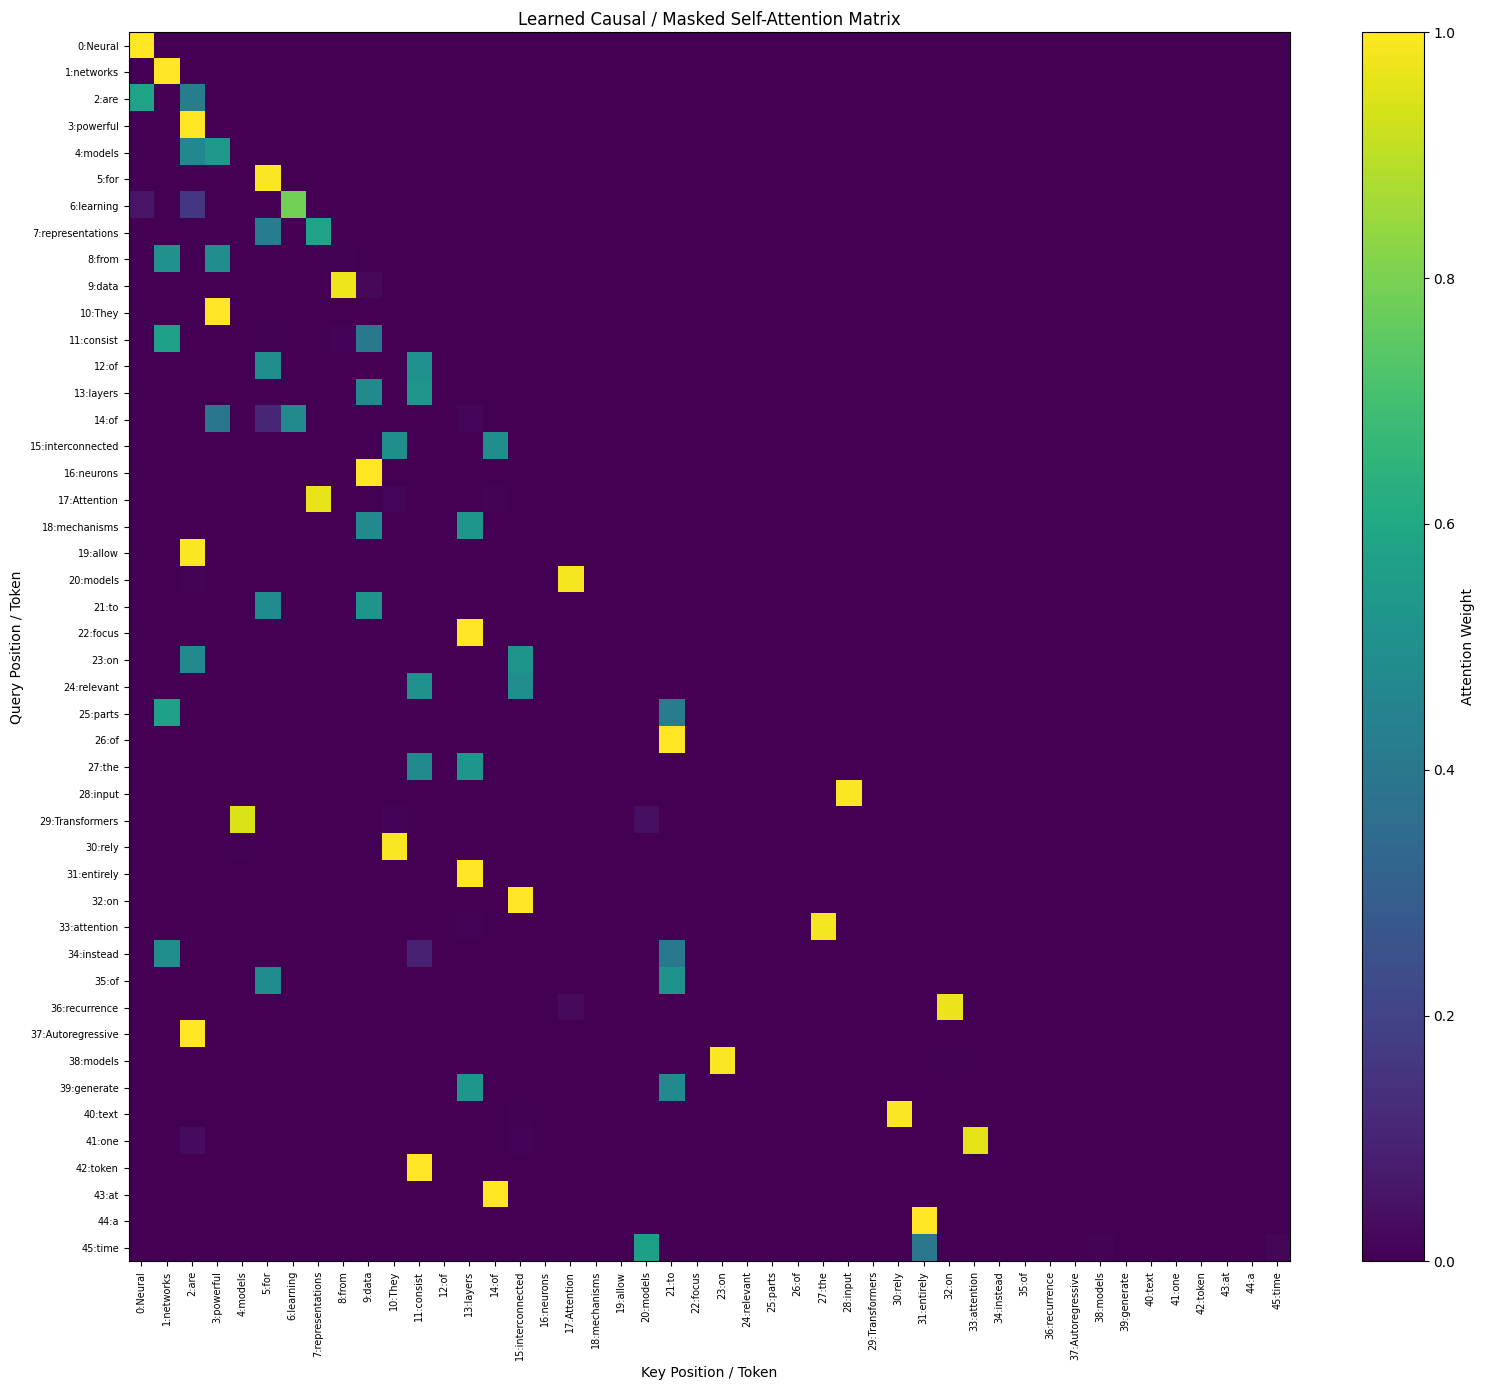

In [57]:
future_attention = torch.triu(
    masked_attention,
    diagonal=1,
)

max_future_attention = (
    future_attention.max().item()
)

total_future_attention = (
    future_attention.sum().item()
)

print(
    "\nMaximum future attention weight:",
    max_future_attention,
)

print(
    "Total future attention mass    :",
    total_future_attention,
)

assert max_future_attention < 1e-7

print(
    "PASS: The causal model does not "
    "attend to future positions."
)


plot_attention_heatmap(
    masked_attention,
    tokens,
    "Learned Causal / Masked Self-Attention Matrix",
    "masked_attention_heatmap.png",
)

### Compare the Two Trained Models

In [58]:
unmasked_future_mass = torch.triu(
    unmasked_attention,
    diagonal=1,
).sum().item()

masked_future_mass = torch.triu(
    masked_attention,
    diagonal=1,
).sum().item()

attention_comparison = pd.DataFrame(
    {
        "Model": [
            "Unmasked Self-Attention",
            "Causal / Masked Self-Attention",
        ],
        "Final Loss": [
            unmasked_final_loss,
            masked_final_loss,
        ],
        "Next-Token Accuracy": [
            unmasked_accuracy,
            masked_accuracy,
        ],
        "Attention Mass Above Diagonal": [
            unmasked_future_mass,
            masked_future_mass,
        ],
    }
)

print("\nAttention model comparison:")
print(attention_comparison.to_string(index=False))


Attention model comparison:
                         Model  Final Loss  Next-Token Accuracy  Attention Mass Above Diagonal
       Unmasked Self-Attention    0.044190             0.978261                      22.102497
Causal / Masked Self-Attention    0.003178             1.000000                       0.000000


### Concrete Token-Level Attention Observations

The code below prints the strongest attended positions for selected query tokens so the heatmaps are interpreted with actual examples.

In [59]:
def top_attention_targets(
    attention,
    labels,
    query_position,
    top_k=5,
):
    """Return the top-k key positions for one query row."""
    row = attention[query_position]

    values, indices = torch.topk(
        row,
        k=min(top_k, len(labels)),
    )

    return pd.DataFrame(
        {
            "Query Position": [
                query_position
            ] * len(indices),
            "Query Token": [
                labels[query_position]
            ] * len(indices),
            "Attended Position": [
                int(i.item())
                for i in indices
            ],
            "Attended Token": [
                labels[int(i.item())]
                for i in indices
            ],
            "Attention Weight": [
                float(v.item())
                for v in values
            ],
        }
    )


example_positions = [
    5,                  # "for"
    len(tokens) // 2,   # position 23, "on"
    len(tokens) - 1,    # position 45, "time"
]

for position in example_positions:
    print(
        f"QUERY POSITION {position}: "
        f"{tokens[position]}"
    )

    print("\nUNMASKED")
    print(
        top_attention_targets(
            unmasked_attention,
            tokens,
            position,
        ).to_string(index=False)
    )

    print("\nMASKED")
    print(
        top_attention_targets(
            masked_attention,
            tokens,
            position,
        ).to_string(index=False)
    )


QUERY POSITION 5: for

UNMASKED
 Query Position Query Token  Attended Position Attended Token  Attention Weight
              5         for                 21             to          0.517301
              5         for                 26             of          0.452015
              5         for                 18     mechanisms          0.011091
              5         for                 35             of          0.009771
              5         for                 12             of          0.005511

MASKED
 Query Position Query Token  Attended Position Attended Token  Attention Weight
              5         for                  5            for          0.995804
              5         for                  3       powerful          0.003465
              5         for                  0         Neural          0.000548
              5         for                  1       networks          0.000127
              5         for                  4         models          0.000053

## Question 2 Findings



*   The single-head implementation uses d_k = d_model = 48. Therefore the scaled dot-product score is divided by sqrt(48), matching the
sqrt(d_k) scaling in Attention Is All You Need.
*   Learned positional embeddings were added in addition to the minimum required
token embeddings. This is necessary because self-attention alone does not
encode sequence order; without positional information, the same set of token
embeddings would not identify which occurrence came first or later.

*  After 600 epochs, the unmasked model reached
97.8% next-token accuracy with loss
0.044. Its total attention mass above the diagonal was
22.10, confirming that query positions were allowed to use
future tokens. For example, in the recorded run query position 5 ('for')
focused strongly on future position 21 ('to') and position 26 ('of').
Query position 23 ('on') also focused on future position 36 ('recurrence').
These off-diagonal future connections are visible in the unmasked heatmap.

*  The unmasked setup is therefore not a valid autoregressive language-model
attention pattern: when predicting the token at t+1 from position t, it is
permitted to inspect positions to the right, including information that would
not be available during real left-to-right generation. This is information
leakage, even though leakage does not guarantee perfect optimization.

*  The separately trained masked model reached
100.0% accuracy with loss 0.003.
Its total attention mass above the diagonal was exactly
0.0, and the numerical assertion confirmed a maximum
future attention weight of 0.0. The heatmap is therefore
strictly lower triangular.

*  Concrete masked-attention examples from the recorded run also show meaningful
backward-looking behavior. Query position 23 ('on') attended mainly to earlier
positions 15 ('interconnected') and 2 ('are'). At the final token, position 45
('time') attended strongly back to position 20 ('models') and position 31
('entirely'). Because no future positions are available to these queries, the
masked model learns to base its prediction only on the current and preceding
context.

*  Interestingly, the masked model performed better than the unmasked model in
this small training experiment: 100.0% versus 97.8% training accuracy and
approximately 0.003 versus 0.044 loss in the recorded run. The important point
is not that masking must always improve training accuracy, but that causal
masking makes the next-token objective valid for autoregressive generation by
preventing future-token leakage.